<a href="https://colab.research.google.com/github/jieun0441/XMC/blob/main/FMC_Figure_3_%26_SI_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 환경 설정 및 폰트 로드

필요한 모든 라이브러리를 임포트하고, Arial 폰트를 다운로드하여 Matplotlib에 설정합니다. 이는 여러 셀에 걸쳐 중복된 코드를 한곳에 모으는 것입니다.


The subtask requests consolidating all necessary library imports and Arial font setup into a single code block. This involves importing specific libraries, downloading the Arial font if not present, adding it to Matplotlib's font manager, and configuring Matplotlib's font settings as specified in the instructions. This directly addresses the subtask requirements.



In [1]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter

print(">> Downloading and setting Arial font and importing libraries...")

# Arial 폰트 다운로드 및 설정
font_url = "https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf"
font_path = "Arial.ttf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
arial_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = arial_prop.get_name()
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['mathtext.default'] = 'regular'

print(">> All libraries imported and Arial font configured for Matplotlib.")

>> Downloading and setting Arial font and importing libraries...
>> All libraries imported and Arial font configured for Matplotlib.


## 데이터 로드 및 전처리

필요한 모든 데이터 파일(인구, 거리, 통행 데이터)을 로드하고, 'clean_id' 함수를 포함한 필요한 전처리를 수행합니다. 'id_to_idx', 'weights_pop', 'Pj_pop', 'D', 'T_nw', 'T_w' 등 이후 단계에서 필요한 모든 변수를 준비합니다.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

data_dir = "/content/drive/MyDrive/FMC_Data/Sharing_to_Public"

def clean_id(x):
    s = str(x).strip()
    if s.endswith('.0'):
        return s[:-2]
    return s

print(">> Loading and preprocessing data...")

# Population Data (Weights)
df_pop = pd.read_excel(os.path.join(data_dir, "population_Seoul_426dong_2023.xlsx"), sheet_name="Sheet1", engine="openpyxl")
df_pop["dong_cd"] = df_pop["dong_cd"].apply(clean_id)
dong_ids = df_pop["dong_cd"].tolist()
weights_pop = df_pop.set_index("dong_cd").loc[dong_ids, "defacto_pop"].astype(float).fillna(0.0).clip(lower=0.0).to_numpy()
Pj_pop = weights_pop

id_to_idx = {d: i for i, d in enumerate(dong_ids)}
n = len(dong_ids)

# Distance Matrix
df_dist_radius = pd.read_csv(os.path.join(data_dir, "Distance_Matrix_dong_to_dong_in_Seoul_MBData_code_system_if_same_filled_radius_assuming_circle.csv"), dtype={"O_ADMDONG_CD": str, "D_ADMDONG_CD": str})
D = np.full((n, n), np.nan, dtype=float)
for _, row in df_dist_radius.iterrows():
    i, j = id_to_idx.get(clean_id(row["O_ADMDONG_CD"])), id_to_idx.get(clean_id(row["D_ADMDONG_CD"]))
    if i is not None and j is not None:
        D[i, j] = float(row["Distance"])
D_pos = np.maximum(D, 1e-12)

# Trip Data
usecols_t = ["O_ADMDONG_CD", "D_ADMDONG_CD", "CNT"]
df_T_nw = pd.read_excel(os.path.join(data_dir, "Tij_NonworkTrips_P24567_in2023.xlsx"), usecols=usecols_t, engine="openpyxl")
df_T_w  = pd.read_excel(os.path.join(data_dir, "Tij_P1_Going_to_Work_in2023.xlsx"), usecols=usecols_t, engine="openpyxl")

T_nw, T_w = np.zeros((n, n), dtype=float), np.zeros((n, n), dtype=float)
for df_T, T_mat in [(df_T_nw, T_nw), (df_T_w, T_w)]:
    for _, row in df_T.iterrows():
        i, j = id_to_idx.get(clean_id(row["O_ADMDONG_CD"])), id_to_idx.get(clean_id(row["D_ADMDONG_CD"]))
        if i is not None and j is not None:
            T_mat[i, j] = pd.to_numeric(row["CNT"], errors="coerce")

print(">> Data loading and preprocessing complete. Variables (id_to_idx, weights_pop, Pj_pop, D, D_pos, T_nw, T_w) are prepared.")


Mounted at /content/drive
>> Loading and preprocessing data...
>> Data loading and preprocessing complete. Variables (id_to_idx, weights_pop, Pj_pop, D, D_pos, T_nw, T_w) are prepared.


## 핵심 시뮬레이션 함수 정의

모델 시뮬레이션(build_P_modelC, build_P_modelD, simulate_from_OT), SC 및 PE 계산(compute_PE, mean_SC_PE_empOT, SC_share_from), KS 거리 계산(ks_distance_weighted) 등 모든 핵심 함수들을 정의합니다.



The subtask requires defining several core functions for model simulation, SC and PE calculation, and KS distance calculation. I will define all these functions in a single code block as specified in the instructions.



In [5]:
print(">> Defining core simulation and analysis functions...")

def build_P_modelC(D_pos, gamma):
    """Model C의 확률 행렬 P를 구축합니다."""
    with np.errstate(divide='ignore', invalid='ignore'):
        W = np.power(D_pos, -gamma, dtype=float)
    W[(~np.isfinite(W)) | (W < 0)] = 0.0
    P = np.zeros_like(W, dtype=float)
    for i in range(W.shape[0]):
        s = W[i].sum()
        P[i, :] = (W[i] / s) if s > 0 else (np.ones(W.shape[1]) / W.shape[1])
    return P

def build_P_modelD(D_pos, gamma, Pj):
    """Model D의 확률 행렬 P를 구축합니다."""
    with np.errstate(divide='ignore', invalid='ignore'):
        W0 = np.power(D_pos, -gamma, dtype=float)
    W0[(~np.isfinite(W0)) | (W0 < 0)] = 0.0
    w_mat = W0 * Pj
    P = np.zeros_like(W0, dtype=float)
    for i in range(W0.shape[0]):
        s = w_mat[i].sum()
        P[i, :] = (w_mat[i] / s) if s > 0 else (np.ones(W0.shape[1]) / W0.shape[1])
    return P

def simulate_from_OT(OT_vec, P_mat, rng):
    """출발 통행 벡터와 확률 행렬을 사용하여 시뮬레이션된 통행 행렬을 생성합니다."""
    n = len(OT_vec)
    T_sim = np.zeros((n, n), dtype=float)
    for i in range(n):
        n_i = int(np.rint(float(OT_vec[i])))
        if n_i > 0:
            T_sim[i, :] = rng.multinomial(n_i, P_mat[i], size=1)[0]
    return T_sim

def compute_PE(T):
    """통행 행렬 T를 사용하여 목적지 인구 비율(PE)을 계산합니다."""
    total = T.sum()
    IT = T.sum(axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(total > 0, IT / total, 0.0)

def mean_SC_PE_empOT(T_emp, P_mat, N_sims=100, seed=42):
    """Self-Containment (SC) 및 PE의 평균 시뮬레이션 결과를 계산합니다."""
    rng = np.random.default_rng(seed)
    OT_emp = T_emp.sum(axis=1)
    SC_sims, PE_sims = np.zeros((N_sims, T_emp.shape[0])), np.zeros((N_sims, T_emp.shape[0]))
    for s_idx in range(N_sims):
        T_sim = simulate_from_OT(OT_emp, P_mat, rng)
        OT = T_sim.sum(axis=1)
        diag = np.diag(T_sim)
        SC = np.zeros_like(OT, dtype=float)
        m = OT > 0
        SC[m] = diag[m] / OT[m]
        SC_sims[s_idx, :] = SC
        PE_sims[s_idx, :] = compute_PE(T_sim)
    return SC_sims.mean(axis=0), PE_sims.mean(axis=0)

def ks_distance_weighted(a, b, w_a, w_b):
    """두 분포와 각각의 가중치를 사용하여 가중 콜모고로프-스미르노프(KS) 거리를 계산합니다."""
    a, b, w_a, w_b = map(lambda x: np.asarray(x, float), (a, b, w_a, w_b))
    ma = np.isfinite(a) & np.isfinite(w_a) & (w_a >= 0)
    mb = np.isfinite(b) & np.isfinite(w_b) & (w_b >= 0)
    a, w_a = a[ma], w_a[ma]
    b, w_b = b[mb], w_b[mb]
    sa, sb = w_a.sum(), w_b.sum()
    if sa <= 0 or sb <= 0 or a.size < 2 or b.size < 2: return np.inf
    w_a, w_b = w_a / sa, w_b / sb
    ia, ib = np.argsort(a), np.argsort(b)
    a_s, wa_s, b_s, wb_s = a[ia], w_a[ia], b[ib], w_b[ib]
    xs = np.unique(np.concatenate([a_s, b_s]))
    cdfa = np.interp(xs, a_s, np.cumsum(wa_s), left=0, right=1)
    cdfb = np.interp(xs, b_s, np.cumsum(wb_s), left=0, right=1)
    return float(np.max(np.abs(cdfa - cdfb)))

def SC_share_from(T):
    """통행 행렬 T를 사용하여 Self-Containment (SC) 비율을 계산합니다."""
    OT, diag = T.sum(axis=1), np.diag(T)
    SC = np.zeros_like(OT, dtype=float)
    m = OT > 0
    SC[m] = diag[m] / OT[m]
    return SC

print(">> All core functions defined.")

>> Defining core simulation and analysis functions...
>> All core functions defined.


## 최적 감마(Gamma) 값 찾기

주어진 GAMMA_GRID를 사용하여 Model C와 Model D에 대한 최적의 감마 값을 계산합니다. 이 과정은 'best_params' 딕셔너리를 채우고, Figure 3와 보조 그림에 사용될 것입니다.


The subtask requires defining constants, initializing dictionaries for targets, datasets, and best_params, and then iterating through GAMMA_GRID to find the optimal gamma values by calculating KS distances for Model C and Model D for both SC and PE metrics. This code block will perform all these calculations and store the results in `best_params`.



In [6]:
N_SIMS = 100
GAMMA_GRID = np.linspace(0.2, 3.0, 60)

# 2. targets 딕셔너리 초기화
targets = {
    "nw": {"SC": SC_share_from(T_nw), "PE": compute_PE(T_nw)},
    "w" : {"SC": SC_share_from(T_w),  "PE": compute_PE(T_w)}
}
# 3. datasets 딕셔너리 초기화
datasets = {"nw": T_nw, "w": T_w}

# 4. best_params 딕셔너리 초기화
best_params = {k: {"C": {"gamma": np.nan, "KS": np.inf}, "D": {"gamma": np.nan, "KS": np.inf}}
               for k in ["SC_nw", "SC_w", "PE_nw", "PE_w"]}

print(">> Optimizing Gamma (This may take a minute)...")
# 5. GAMMA_GRID의 각 감마 값에 대해 중첩 루프 실행
for label in ["nw", "w"]:
    T_emp = datasets[label]
    for g in GAMMA_GRID:
        # a. P_C 및 P_D 확률 행렬 구축
        P_C, P_D = build_P_modelC(D_pos, g), build_P_modelD(D_pos, g, Pj_pop)

        # b. SC_C, PE_C, SC_D, PE_D 계산
        SC_C, PE_C = mean_SC_PE_empOT(T_emp, P_C, N_sims=N_SIMS)
        SC_D, PE_D = mean_SC_PE_empOT(T_emp, P_D, N_sims=N_SIMS)

        # c, d. 가중 KS 거리 계산 및 best_params 업데이트
        for q, emp_C, emp_D in [("SC", SC_C, SC_D), ("PE", PE_C, PE_D)]:
            key = f"{q}_{label}"
            ksC = ks_distance_weighted(targets[label][q], emp_C, weights_pop, weights_pop)
            ksD = ks_distance_weighted(targets[label][q], emp_D, weights_pop, weights_pop)
            if ksC < best_params[key]["C"]["KS"]: best_params[key]["C"] = {"gamma": g, "KS": ksC}
            if ksD < best_params[key]["D"]["KS"]: best_params[key]["D"] = {"gamma": g, "KS": ksD}

print(">> Gamma optimization complete. best_params dictionary populated.")

>> Optimizing Gamma (This may take a minute)...
>> Gamma optimization complete. best_params dictionary populated.


## Figure 3 그리기

최적화된 감마 값을 사용하여 Figure 3를 그립니다. 이 단계에서는 'a2s-mODEZZjn' 셀의 가장 정제된 플로팅 로직을 사용하여 색상 테마, 폰트 크기, 범례 및 축 레이블을 적용하고 그림을 PDF 및 JPG 형식으로 저장합니다.


The subtask requires generating Figure 3 by consolidating the plotting logic from the specified cell ('a2s-mODEZZjn') and applying specific styling, then saving the output. This code block will define the helper function, set up color themes, figure dimensions, formatters, iterate through panels to plot histograms with detailed styling for empirical, Model C (dotted), and Model D (solid) data, and finally save the plot as PDF and JPG.



>> Plotting Figure 3 (Refined Lines, Colors & Legends)...


>> [Saved] /content/drive/MyDrive/FMC_Data/Combined_Figure/Figure3_Combined_Final.pdf
>> [Saved] /content/drive/MyDrive/FMC_Data/Combined_Figure/Figure3_Combined_Final.jpg


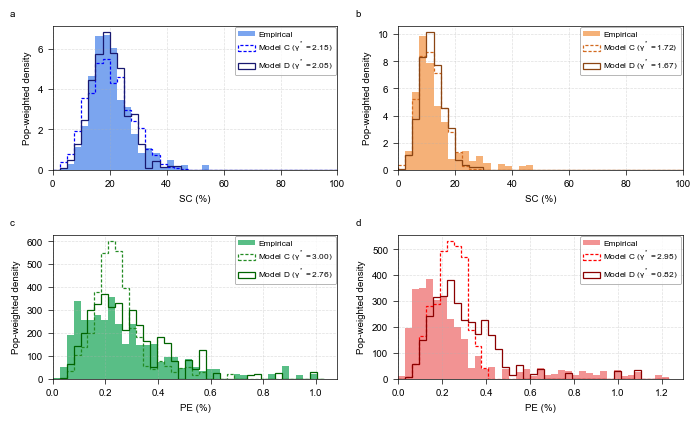

In [7]:
print(">> Plotting Figure 3 (Refined Lines, Colors & Legends)...\n")

def _SC_PE_from_gamma(label, gamma, model="C"):
    """주어진 label, gamma, model에 따라 SC 및 PE 시뮬레이션 결과를 반환합니다."""
    T_emp = datasets[label]
    P = build_P_modelC(D_pos, gamma) if model == "C" else build_P_modelD(D_pos, gamma, Pj_pop)
    return mean_SC_PE_empOT(T_emp, P, N_sims=N_SIMS)

# Figure 3와 완벽하게 동일한 색상 테마 명시적 정의
color_themes = {
    'SC_nw': {'emp': 'cornflowerblue', 'C': 'blue',        'D': 'midnightblue'},
    'SC_w':  {'emp': 'sandybrown',     'C': 'chocolate',   'D': 'saddlebrown'},
    'PE_nw': {'emp': 'mediumseagreen', 'C': 'forestgreen', 'D': 'darkgreen'},
    'PE_w':  {'emp': 'lightcoral',     'C': 'red',         'D': 'darkred'}
}

# 180mm = 7.08 inches
fig_width = 180 / 25.4
fig_height = 110 / 25.4
fig, axs = plt.subplots(2, 2, figsize=(fig_width, fig_height))

def format_pct_SC(x, pos): return f"{x * 100:.0f}"
def format_pct_PE(x, pos): return f"{x * 100:.1f}"

panels = [
    (axs[0,0], "nw", "SC", "a"),
    (axs[0,1], "w",  "SC", "b"),
    (axs[1,0], "nw", "PE", "c"),
    (axs[1,1], "w",  "PE", "d")
]

MAX_FONT = 7
LEGEND_FONT = 6

for ax, label, quantity, p_label in panels:
    x_emp = targets[label][quantity]
    gC, gD = best_params[f"{quantity}_{label}"]["C"]["gamma"], best_params[f"{quantity}_{label}"]["D"]["gamma"]

    val_C, val_D = _SC_PE_from_gamma(label, gC, model="C"), _SC_PE_from_gamma(label, gD, model="D")
    xC = val_C[0] if quantity == "SC" else val_C[1]
    xD = val_D[0] if quantity == "SC" else val_D[1]

    valid = np.isfinite(x_emp) & np.isfinite(weights_pop) & (weights_pop >= 0)
    w = weights_pop[valid]
    theme = color_themes[f"{quantity}_{label}"]

    if quantity == "SC":
        bins = np.linspace(0.0, 1.0, 41)
        ax.set_xlabel('SC (%)', fontsize=MAX_FONT)
        ax.xaxis.set_major_formatter(FuncFormatter(format_pct_SC))
        ax.set_xlim(0, 1.0)
        ax.set_xticks(np.arange(0, 1.01, 0.2))
    else:
        all_vals = np.concatenate([x_emp[valid], xC[valid], xD[valid]])
        xmax = np.percentile(all_vals, 99.5) if all_vals.size else 0.01
        if xmax <= 0: xmax = 0.01
        bins = np.linspace(0.0, float(xmax), 40)
        ax.set_xlabel('PE (%)', fontsize=MAX_FONT)
        ax.xaxis.set_major_formatter(FuncFormatter(format_pct_PE))
        ax.set_xlim(0, float(xmax * 1.05))

    # 1. Empirical 베이스 색상
    ax.hist(x_emp[valid], bins=bins, density=True, weights=w, alpha=0.85, color=theme['emp'], label="Empirical")

    # 2. Model C - 기본 선으로 먼저 그리고 -> 커스텀 점선 덧씌우기
    patches_C = ax.hist(xC[valid], bins=bins, density=True, weights=w, histtype='step',
                              linewidth=0.9, color=theme['C'], label=rf"Model C ($\gamma^*=${gC:.2f})")[2]
    patches_C[0].set_linestyle((0, (2.5, 1.5))) # 촘촘한 점선 적용

    # 3. Model D - 실선
    ax.hist(xD[valid], bins=bins, density=True, weights=w, histtype='step',
            linewidth=0.9, linestyle='-', color=theme['D'], label=rf"Model D ($\gamma^*=${gD:.2f})")

    ax.set_ylabel("Pop-weighted density", fontsize=MAX_FONT)
    ax.tick_params(axis='both', which='major', labelsize=MAX_FONT, width=0.5)
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)

    for spine in ax.spines.values(): spine.set_linewidth(0.5)

    ax.text(-0.15, 1.05, p_label, transform=ax.transAxes, fontsize=MAX_FONT, fontweight='bold', va='bottom', ha='left')

    legend = ax.legend(loc='upper right',
                       fontsize=LEGEND_FONT,
                       frameon=True,
                       labelspacing=0.25,
                       handletextpad=0.4,
                       borderaxespad=0.2)

    legend.get_frame().set_linewidth(0.5)
    legend.get_frame().set_edgecolor('grey') # legend outline color

plt.tight_layout()

# 저장
PDF_DIR = "/content/drive/MyDrive/FMC_Data/Combined_Figure/"
os.makedirs(PDF_DIR, exist_ok=True)
save_path_pdf = os.path.join(PDF_DIR, "Figure3_Combined_Final.pdf")
save_path_jpg = os.path.join(PDF_DIR, "Figure3_Combined_Final.jpg")
plt.savefig(save_path_pdf, bbox_inches="tight")
plt.savefig(save_path_jpg, dpi=300, bbox_inches="tight")
print(f"\n>> [Saved] {save_path_pdf}")
print(f">> [Saved] {save_path_jpg}")

plt.show()

## KS 거리 추적 데이터 계산 (보조 그림용)

보조 그림에 필요한 감마 값에 따른 KS 거리 추적 데이터를 계산합니다. 'GAMMA_GRID'의 각 감마 값에 대해 Model C 및 Model D의 SC 및 PE에 대한 KS 거리를 계산하고 'ks_traces' 딕셔너리에 저장합니다.


The subtask requires calculating the KS distance traces for all gamma values in `GAMMA_GRID` for both Model C and Model D, and for both SC and PE metrics. This involves initializing a `ks_traces` dictionary, iterating through labels and gamma values, calculating model predictions, and then computing and storing the weighted KS distances.



In [8]:
print(">> Calculating KS distance traces for supplementary figure...")

# 1. 'ks_traces' 딕셔너리 초기화
ks_traces = {
    "SC_nw": {"C": np.zeros(len(GAMMA_GRID)), "D": np.zeros(len(GAMMA_GRID))},
    "SC_w":  {"C": np.zeros(len(GAMMA_GRID)), "D": np.zeros(len(GAMMA_GRID))},
    "PE_nw": {"C": np.zeros(len(GAMMA_GRID)), "D": np.zeros(len(GAMMA_GRID))},
    "PE_w":  {"C": np.zeros(len(GAMMA_GRID)), "D": np.zeros(len(GAMMA_GRID))}
}

# 2. 'nw'와 'w' 두 라벨에 대해 반복합니다.
for label in ["nw", "w"]:
    T_emp = datasets[label]
    # 3. 각 라벨 내에서 'GAMMA_GRID'의 모든 감마 값에 대해 반복합니다.
    for gi, g in enumerate(GAMMA_GRID):
        # 4. 현재 감마 값을 사용하여 'build_P_modelC' 및 'build_P_modelD' 함수를 호출하여 'P_C'와 'P_D' 확률 행렬을 각각 생성합니다.
        P_C = build_P_modelC(D_pos, g)
        P_D = build_P_modelD(D_pos, g, Pj_pop)

        # 5. 'mean_SC_PE_empOT' 함수를 호출하여 'P_C'와 'P_D'에 대한 SC 및 PE 값을 계산합니다.
        SC_C, PE_C = mean_SC_PE_empOT(T_emp, P_C, N_sims=N_SIMS)
        SC_D, PE_D = mean_SC_PE_empOT(T_emp, P_D, N_sims=N_SIMS)

        # 6. 'ks_distance_weighted' 함수를 사용하여 가중 KS 거리를 계산합니다.
        # 7. 계산된 KS 거리를 'ks_traces' 딕셔너리 내의 적절한 위치에 저장합니다.
        ks_traces[f"SC_{label}"]["C"][gi] = ks_distance_weighted(targets[label]["SC"], SC_C, weights_pop, weights_pop)
        ks_traces[f"SC_{label}"]["D"][gi] = ks_distance_weighted(targets[label]["SC"], SC_D, weights_pop, weights_pop)

        ks_traces[f"PE_{label}"]["C"][gi] = ks_distance_weighted(targets[label]["PE"], PE_C, weights_pop, weights_pop)
        ks_traces[f"PE_{label}"]["D"][gi] = ks_distance_weighted(targets[label]["PE"], PE_D, weights_pop, weights_pop)

print(">> KS distance trace calculation complete. 'ks_traces' dictionary populated.")

>> Calculating KS distance traces for supplementary figure...
>> KS distance trace calculation complete. 'ks_traces' dictionary populated.


## 보조 그림 (KS-trace) 그리기

이전 단계에서 계산된 KS 거리 추적 데이터를 사용하여 보조 그림을 그립니다. 'gQp5g6MVl_Dy' 셀의 가장 정제된 플로팅 로직을 사용하여 최적의 감마 값에 대한 마커, 텍스트 위치, 일치하는 색상 및 세부 서식을 적용하고 그림을 PDF 및 JPG 형식으로 저장합니다.


The subtask requires generating the supplementary figure (KS-trace) using the refined plotting logic from cell 'gQp5g6MVl_Dy'. This involves setting up subplots, plotting KS traces for Model C and D with specific line styles and colors, adding markers and finely tuned text labels for optimal gamma values, and applying consistent aesthetic settings before saving and displaying the plot.



>> Plotting Supplementary Figure (Final Position Tweak)...


>> [Saved] /content/drive/MyDrive/FMC_Data/Combined_Figure/Supp_Figure_KS_Trace_Final.pdf
>> [Saved] /content/drive/MyDrive/FMC_Data/Combined_Figure/Supp_Figure_KS_Trace_Final.jpg


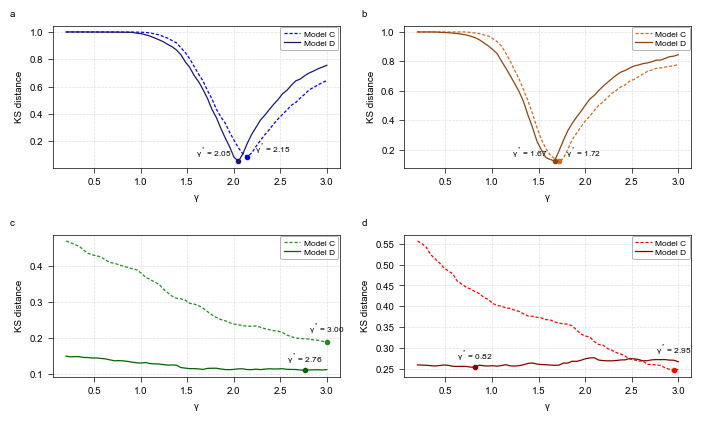

In [9]:
print(">> Plotting Supplementary Figure (Final Position Tweak)...\n")

# 180mm = 7.08 inches
fig_width = 180 / 25.4
fig_height = 110 / 25.4
fig, axs = plt.subplots(2, 2, figsize=(fig_width, fig_height))

MAX_FONT = 7
LEGEND_FONT = 6

panels_ks = [
    (axs[0,0], "SC_nw", "a"),
    (axs[0,1], "SC_w",  "b"),
    (axs[1,0], "PE_nw", "c"),
    (axs[1,1], "PE_w",  "d")
]

for ax, key, p_label in panels_ks:
    ksC = ks_traces[key]["C"]
    ksD = ks_traces[key]["D"]
    theme = color_themes[key]

    # Trace 플롯
    ax.plot(GAMMA_GRID, ksC, lw=0.9, color=theme['C'], linestyle=(0, (2.5, 1.5)), label="Model C")
    ax.plot(GAMMA_GRID, ksD, lw=0.9, color=theme['D'], linestyle='-', label="Model D")

    # [핵심 수정] 텍스트 위치 최적화
    if np.any(np.isfinite(ksC)):
        iC = int(np.nanargmin(ksC))
        ax.plot(GAMMA_GRID[iC], ksC[iC], 'o', color=theme['C'], markersize=3)

        if 'SC' in key:
            text_pos = (GAMMA_GRID[iC] + 0.08, ksC[iC] + 0.005)
            ha, va = 'left', 'bottom'
        elif key == 'PE_w':
            # 패널 d: Model C는 더 위로 이동
            text_pos = (GAMMA_GRID[iC], ksC[iC] + 0.030)
            ha, va = 'center', 'bottom'
        else:
            # 패널 c: 기본 위치
            text_pos = (GAMMA_GRID[iC], ksC[iC] + 0.015)
            ha, va = 'center', 'bottom'

        ax.text(text_pos[0], text_pos[1], rf"$\gamma^*={GAMMA_GRID[iC]:.2f}$",
                fontsize=LEGEND_FONT, color='black', ha=ha, va=va)

    if np.any(np.isfinite(ksD)):
        iD = int(np.nanargmin(ksD))
        ax.plot(GAMMA_GRID[iD], ksD[iD], 'o', color=theme['D'], markersize=3)

        if 'SC' in key:
            text_pos = (GAMMA_GRID[iD] - 0.08, ksD[iD] + 0.005)
            ha, va = 'right', 'bottom'
        else:
            # [수정] 패널 c, d 공통: Model D 텍스트를 포인트에 더 가깝게 붙임 (0.005)
            text_pos = (GAMMA_GRID[iD], ksD[iD] + 0.010)
            ha, va = 'center', 'bottom'

        ax.text(text_pos[0], text_pos[1], rf"$\gamma^*={GAMMA_GRID[iD]:.2f}$",
                fontsize=LEGEND_FONT, color='black', ha=ha, va=va)

    # 축 서식
    ax.set_ylabel("KS distance", fontsize=MAX_FONT)
    ax.set_xlabel(r"$\gamma$", fontsize=MAX_FONT)
    ax.tick_params(axis='both', which='major', labelsize=MAX_FONT, width=0.5)
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

    ax.text(-0.15, 1.05, p_label, transform=ax.transAxes, fontsize=MAX_FONT, fontweight='bold', va='bottom', ha='left')

    # 범례 서식
    legend = ax.legend(loc='upper right', fontsize=LEGEND_FONT, frameon=True,
                       labelspacing=0.25, handletextpad=0.4, borderaxespad=0.2)
    legend.get_frame().set_linewidth(0.5)
    legend.get_frame().set_edgecolor('#808080')

plt.tight_layout()

# 저장
PDF_DIR = "/content/drive/MyDrive/FMC_Data/Combined_Figure/"
os.makedirs(PDF_DIR, exist_ok=True)

save_path_pdf_ks = os.path.join(PDF_DIR, "Supp_Figure_KS_Trace_Final.pdf")
save_path_jpg_ks = os.path.join(PDF_DIR, "Supp_Figure_KS_Trace_Final.jpg")
plt.savefig(save_path_pdf_ks, bbox_inches="tight")
plt.savefig(save_path_jpg_ks, dpi=300, bbox_inches="tight")

print(f"\n>> [Saved] {save_path_pdf_ks}")
print(f">> [Saved] {save_path_jpg_ks}")

plt.show()


The final image files are saved to:
- `/content/drive/MyDrive/FMC_Data/Combined_Figure/Figure3_Combined_Final.pdf`
- `/content/drive/MyDrive/FMC_Data/Combined_Figure/Figure3_Combined_Final.jpg`
- `/content/drive/MyDrive/FMC_Data/Combined_Figure/Supp_Figure_KS_Trace_Final.pdf`
- `/content/drive/MyDrive/FMC_Data/Combined_Figure/Supp_Figure_KS_Trace_Final.jpg`